In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/production_data.csv")
df.head()


,Date,Shift,Work_Center,Units_Started,Units_Completed,Defects,Downtime_Minutes,Operator_Count
0,2025-01-01,Morning,Winding,45,42,1,10,6
1,2025-01-01,Evening,Assembly,38,35,2,20,7
2,2025-01-01,Night,Cooling,30,28,3,25,5
3,2025-01-02,Morning,Winding,50,47,1,12,6
4,2025-01-02,Evening,Assembly,40,36,3,18,7


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              30 non-null     datetime64[ns]
 1   Shift             30 non-null     object        
 2   Work_Center       30 non-null     object        
 3   Units_Started     30 non-null     int64         
 4   Units_Completed   30 non-null     int64         
 5   Defects           30 non-null     int64         
 6   Downtime_Minutes  30 non-null     int64         
 7   Operator_Count    30 non-null     int64         
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 2.0+ KB


,Date,Units_Started,Units_Completed,Defects,Downtime_Minutes,Operator_Count
count,30,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2025-01-05 12:00:00,39.833333,37.266667,2.166667,18.666667,6.000000
min,2025-01-01 00:00:00,28.000000,27.000000,1.000000,7.000000,5.000000
25%,2025-01-03 00:00:00,33.000000,30.250000,1.000000,12.250000,5.000000
50%,2025-01-05 12:00:00,38.500000,36.000000,2.000000,20.000000,6.000000
75%,2025-01-08 00:00:00,47.750000,45.500000,3.000000,24.000000,7.000000
max,2025-01-10 00:00:00,54.000000,52.000000,4.000000,30.000000,7.000000
std,NaN,8.175166,8.161868,0.949894,6.939807,0.830455


In [3]:
df['Completion_Rate'] = df['Units_Completed'] / df['Units_Started']
df['Defect_Rate'] = df['Defects'] / df['Units_Completed']

df.head()


,Date,Shift,Work_Center,Units_Started,Units_Completed,Defects,Downtime_Minutes,Operator_Count,Completion_Rate,Defect_Rate
0,2025-01-01,Morning,Winding,45,42,1,10,6,0.933333,0.023810
1,2025-01-01,Evening,Assembly,38,35,2,20,7,0.921053,0.057143
2,2025-01-01,Night,Cooling,30,28,3,25,5,0.933333,0.107143
3,2025-01-02,Morning,Winding,50,47,1,12,6,0.940000,0.021277
4,2025-01-02,Evening,Assembly,40,36,3,18,7,0.900000,0.083333


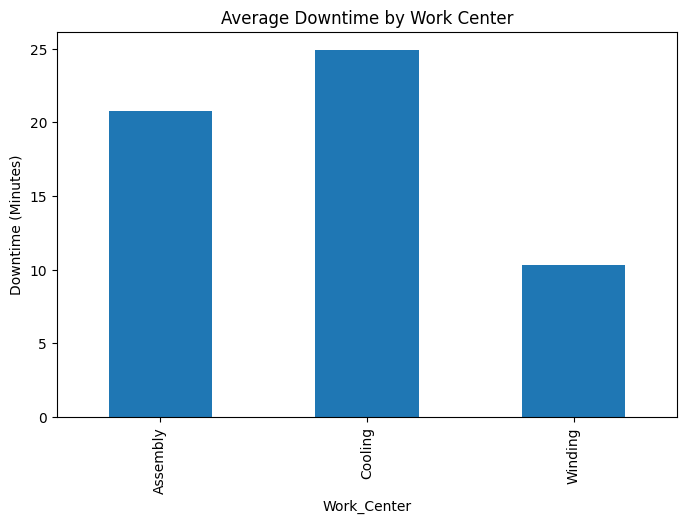

In [4]:
plt.figure(figsize=(8,5))
df.groupby("Work_Center")["Downtime_Minutes"].mean().plot(kind="bar")
plt.title("Average Downtime by Work Center")
plt.ylabel("Downtime (Minutes)")
plt.show()


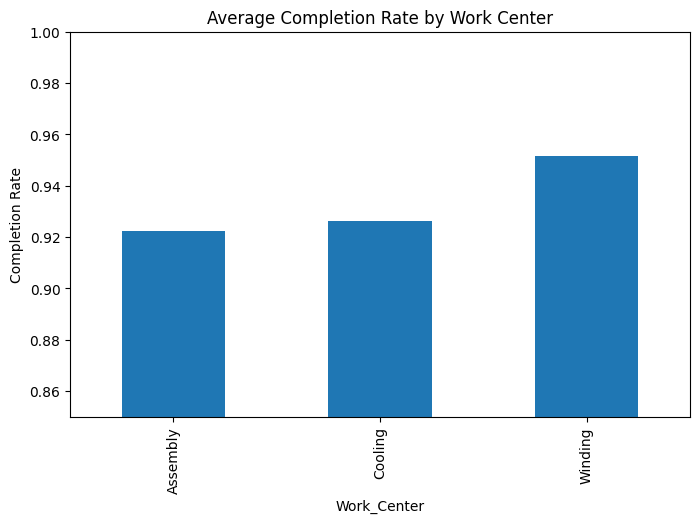

In [5]:
plt.figure(figsize=(8,5))
df.groupby("Work_Center")["Completion_Rate"].mean().plot(kind="bar")
plt.title("Average Completion Rate by Work Center")
plt.ylabel("Completion Rate")
plt.ylim(0.85, 1.0)
plt.show()


In [6]:
kpi_summary = df.groupby("Work_Center").agg({
    "Units_Started": "mean",
    "Units_Completed": "mean",
    "Defects": "mean",
    "Downtime_Minutes": "mean",
    "Completion_Rate": "mean",
    "Defect_Rate": "mean"
})

kpi_summary.round(3)


,Units_Started,Units_Completed,Defects,Downtime_Minutes,Completion_Rate,Defect_Rate
Work_Center,,,,,,
Assembly,38.5,35.5,2.4,20.8,0.923,0.068
Cooling,31.1,28.8,2.9,24.9,0.926,0.101
Winding,49.9,47.5,1.2,10.3,0.952,0.025


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

X = df[['Downtime_Minutes', 'Operator_Count']]
y = df['Completion_Rate']

model.fit(X, y)
predictions = model.predict(X)

df['Predicted_Completion_Rate'] = predictions
df[['Completion_Rate', 'Predicted_Completion_Rate']].head()


,Completion_Rate,Predicted_Completion_Rate
0,0.933333,0.953891
1,0.921053,0.923585
2,0.933333,0.925285
3,0.940000,0.949178
4,0.900000,0.928298


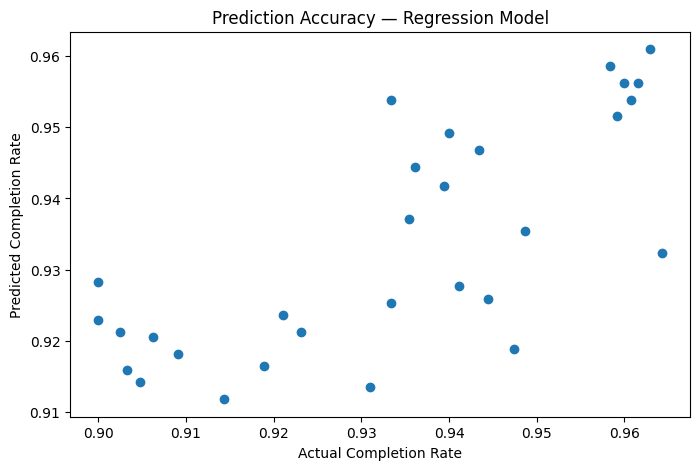

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['Completion_Rate'], df['Predicted_Completion_Rate'])
plt.xlabel("Actual Completion Rate")
plt.ylabel("Predicted Completion Rate")
plt.title("Prediction Accuracy — Regression Model")
plt.show()


In [10]:
cleaned_df = df[['Date','Shift','Work_Center','Units_Started','Units_Completed',
                 'Defects','Downtime_Minutes','Operator_Count',
                 'Completion_Rate','Defect_Rate','Predicted_Completion_Rate']]

cleaned_df.to_csv("../data/cleaned_production_data.csv", index=False)
